# Level 2 Task 2 — Wine Quality Prediction

**Goal:** Predict red wine quality (score 3-8) from its chemical properties, and compare a few different classifiers.

Dataset: UCI Wine Quality (red wine), 1599 samples, 11 chemical features + quality score.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style("whitegrid")

columns = ["fixed_acidity", "volatile_acidity", "citric_acid", "residual_sugar",
           "chlorides", "free_sulfur_dioxide", "total_sulfur_dioxide", "density",
           "pH", "sulphates", "alcohol", "quality"]
df = pd.read_csv("winequality.csv", header=None, names=columns)
df.shape

(1599, 12)

In [2]:
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 1. Inspect structure & class distribution

In [3]:
df.isnull().sum().sum()

np.int64(0)

In [4]:
df["quality"].value_counts().sort_index()

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

/tmp/ipykernel_742/1250251349.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="quality", data=df, palette="viridis")


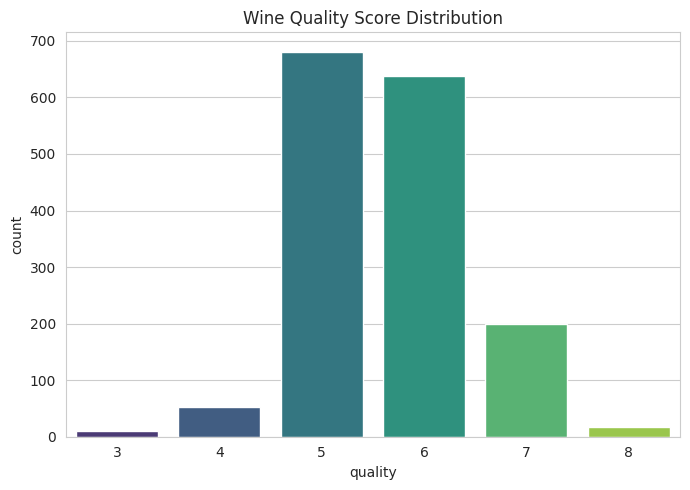

In [5]:
plt.figure(figsize=(7, 5))
sns.countplot(x="quality", data=df, palette="viridis")
plt.title("Wine Quality Score Distribution")
plt.tight_layout()
plt.savefig("quality_distribution.png")
plt.show()

**Observation:** No missing values. Quality scores are heavily concentrated around 5 and 6 — very few wines are rated 3, 4, 7 or 8. This is a classic **class imbalance** situation.

## 2. EDA — feature distributions & correlation

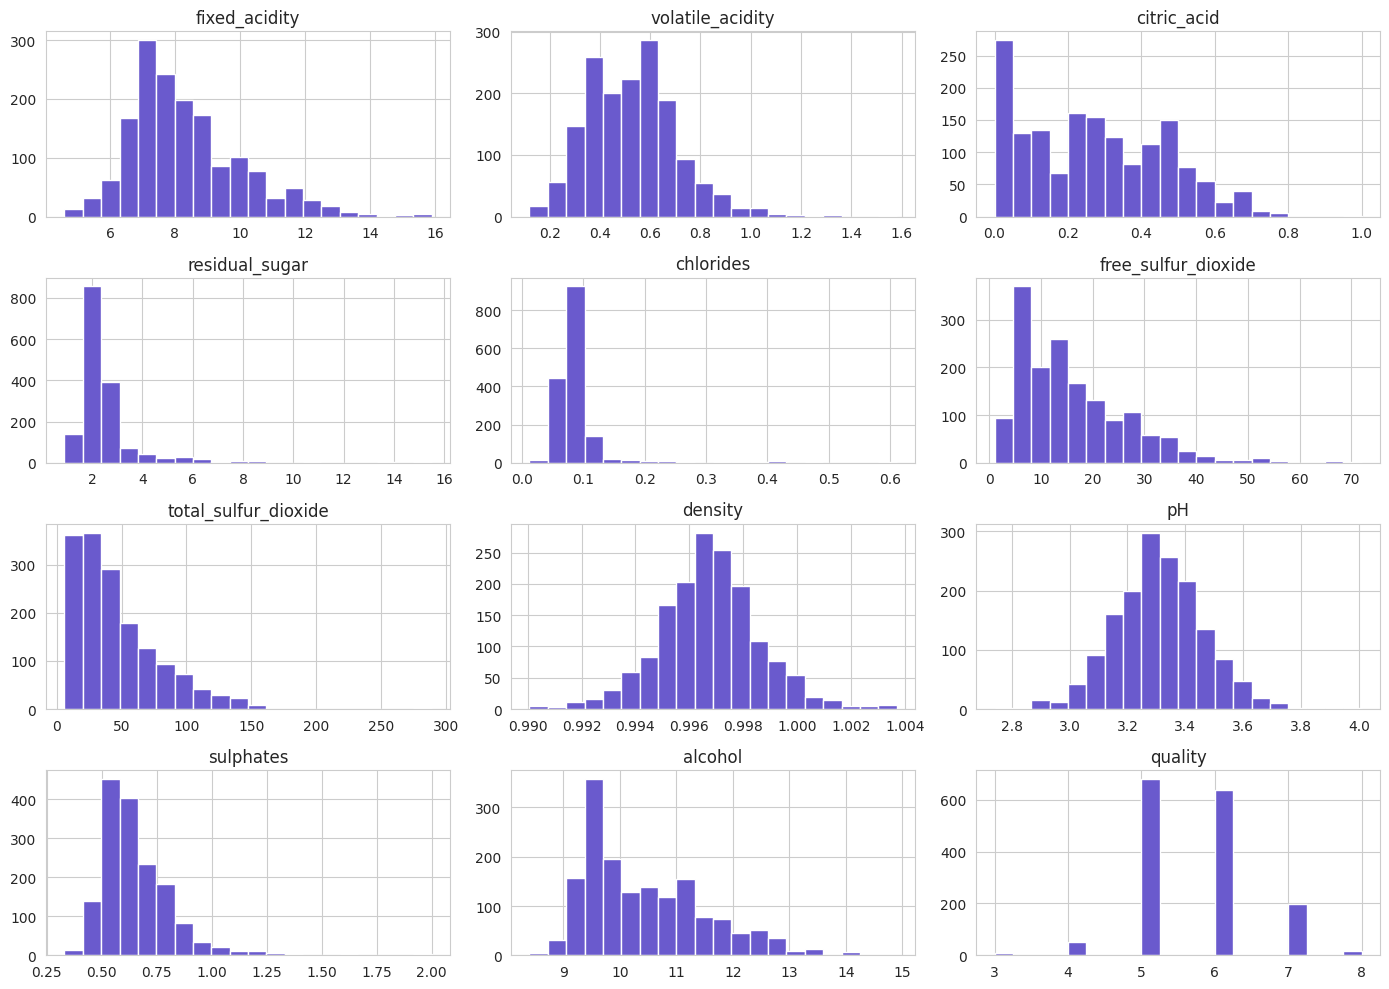

In [6]:
df.hist(figsize=(14, 10), bins=20, color="slateblue")
plt.tight_layout()
plt.savefig("feature_distributions.png")
plt.show()

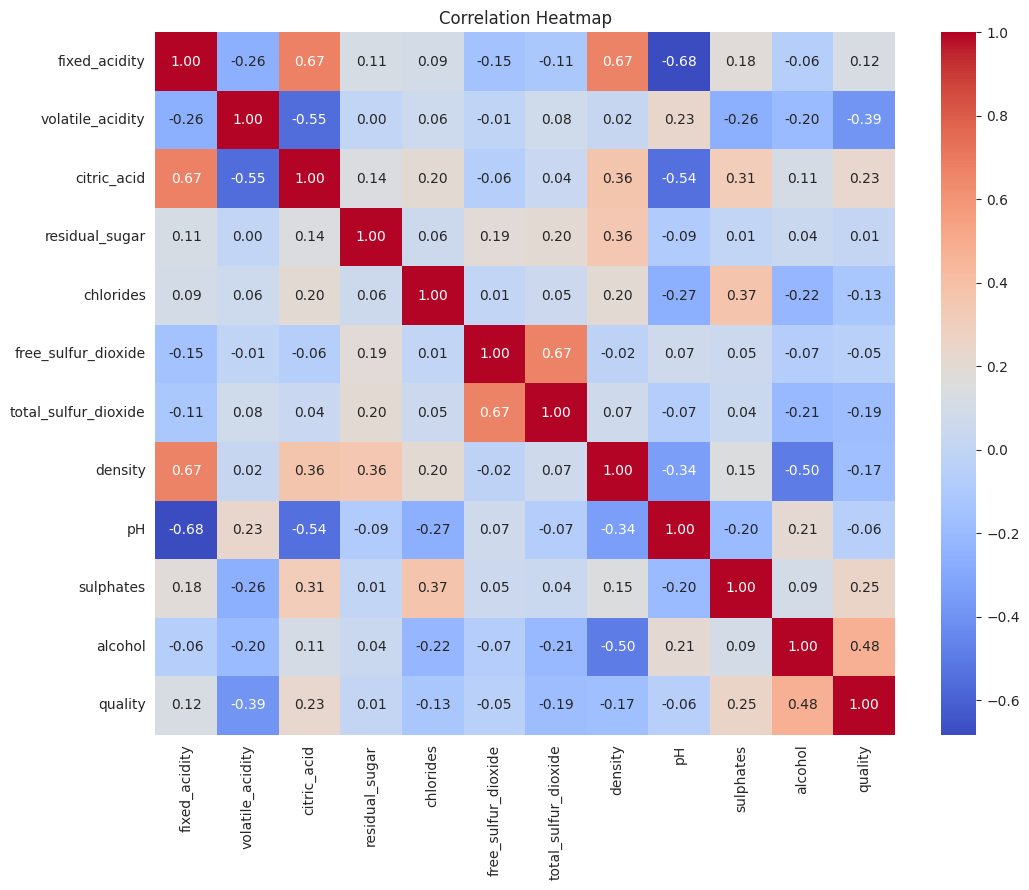

In [7]:
plt.figure(figsize=(11, 9))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.show()

**Observation:** `alcohol` has the strongest positive correlation with `quality` — higher alcohol tends to mean higher rated wine. `volatile_acidity` has a clear negative correlation — more of it (which gives a vinegar-like taste) tends to lower the quality score.

## 3. Class imbalance discussion

As seen above, quality=5 and quality=6 dominate the dataset while quality=3 and quality=8 have only a handful of samples each. This matters because: (a) a classifier can get high overall accuracy just by always predicting 5 or 6 and mostly ignoring rare classes, and (b) with so few examples of quality 3/8, the model has very little signal to actually learn what makes a wine "excellent" or "terrible". To make the problem more learnable, I'm binning quality into 3 buckets: **Low (3-4), Medium (5-6), High (7-8)** — this keeps some signal while giving each class enough samples to be classifiable.

In [8]:
def bin_quality(q):
    if q <= 4:
        return "Low"
    elif q <= 6:
        return "Medium"
    else:
        return "High"

df["quality_bin"] = df["quality"].apply(bin_quality)
df["quality_bin"].value_counts()

quality_bin
Medium    1319
High       217
Low         63
Name: count, dtype: int64

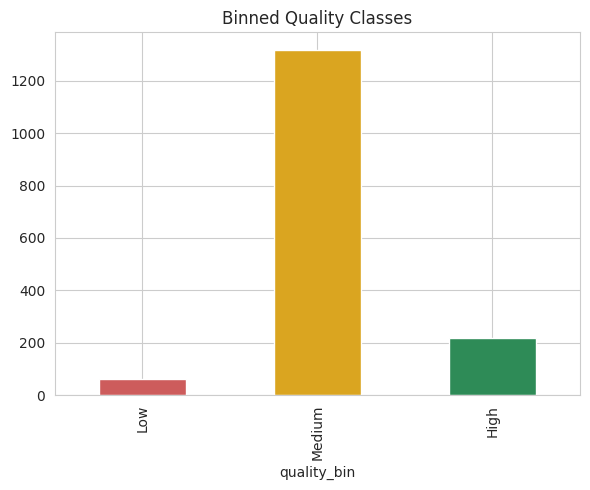

In [9]:
plt.figure(figsize=(6, 5))
df["quality_bin"].value_counts().reindex(["Low", "Medium", "High"]).plot(kind="bar", color=["indianred", "goldenrod", "seagreen"])
plt.title("Binned Quality Classes")
plt.tight_layout()
plt.savefig("binned_quality.png")
plt.show()

**Observation:** "Medium" is still the overwhelming majority even after binning, but "Low" and "High" now each have a reasonable number of samples to work with, compared to almost-empty individual classes (3, 4, 8) before.

## 4. Train/test split with stratification

In [10]:
X = df.drop(columns=["quality", "quality_bin"])
y = df["quality_bin"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train.value_counts(), y_test.value_counts()

(quality_bin
 Medium    1055
 High       174
 Low         50
 Name: count, dtype: int64,
 quality_bin
 Medium    264
 High       43
 Low        13
 Name: count, dtype: int64)

## 5. Train 3 classifiers

In [11]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SGD Classifier": SGDClassifier(random_state=42),
    "SVC": SVC(kernel="rbf", random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    results[name] = pred
    print(f"=== {name} ===")
    print("Accuracy:", round(accuracy_score(y_test, pred), 3))
    print(classification_report(y_test, pred, zero_division=0))

=== Random Forest ===
Accuracy: 0.866
              precision    recall  f1-score   support

        High       0.71      0.51      0.59        43
         Low       0.00      0.00      0.00        13
      Medium       0.88      0.97      0.92       264

    accuracy                           0.87       320
   macro avg       0.53      0.49      0.51       320
weighted avg       0.82      0.87      0.84       320

=== SGD Classifier ===
Accuracy: 0.825
              precision    recall  f1-score   support

        High       0.52      0.33      0.40        43
         Low       0.00      0.00      0.00        13
      Medium       0.86      0.95      0.90       264

    accuracy                           0.82       320
   macro avg       0.46      0.42      0.43       320
weighted avg       0.78      0.82      0.80       320

=== SVC ===
Accuracy: 0.844
              precision    recall  f1-score   support

        High       0.64      0.33      0.43        43
         Low       0.00 

## 6. Confusion matrices

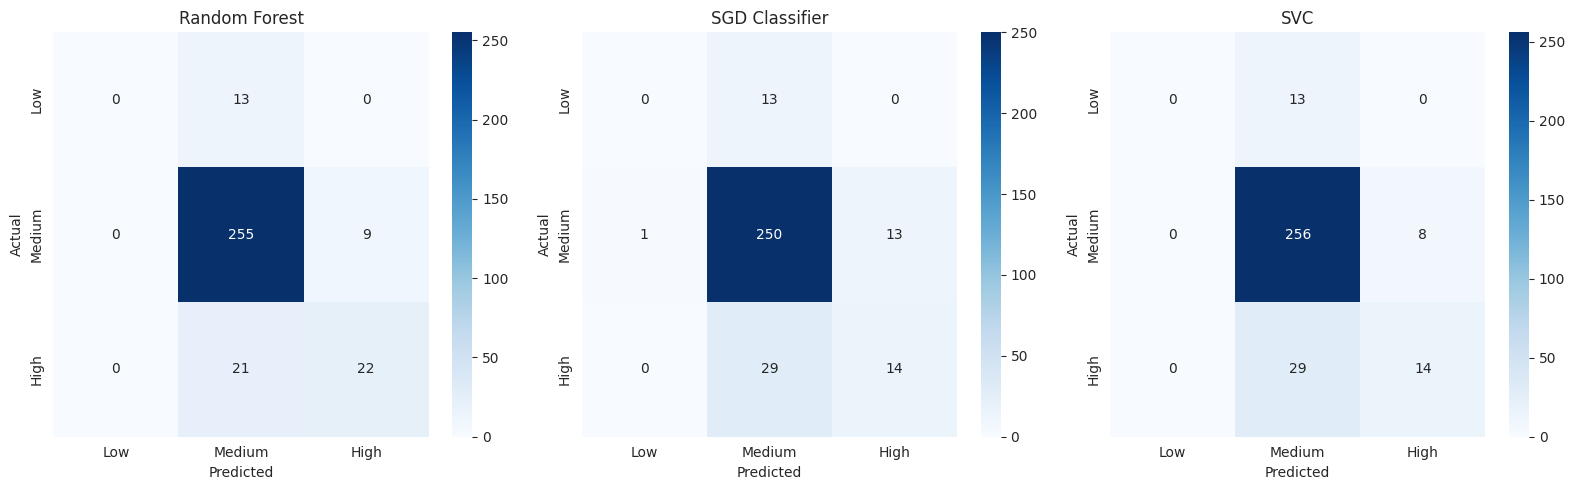

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
labels = ["Low", "Medium", "High"]
for ax, (name, pred) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrices.png")
plt.show()

**Observation:** All 3 models are good at predicting "Medium" (the majority class) but struggle much more with "Low" and "High" — a direct effect of the class imbalance discussed earlier. Random Forest generally handles the minority classes a bit better than SGD and SVC.

## 7. Feature importance (Random Forest)

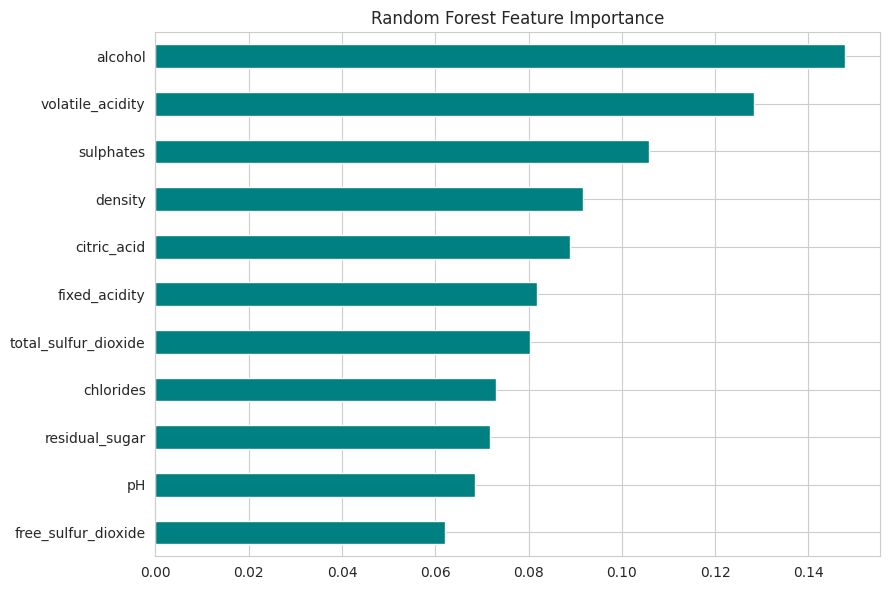

In [13]:
rf_model = models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
importances.plot(kind="barh", color="teal")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

**Observation:** `alcohol` and `sulphates` come out as the most important features for the Random Forest, followed by `volatile_acidity` — this lines up with what the correlation heatmap suggested earlier.

## 8. Model comparison table

In [14]:
comparison = pd.DataFrame({
    name: [accuracy_score(y_test, pred)] for name, pred in results.items()
}, index=["Accuracy"]).T.sort_values("Accuracy", ascending=False)
comparison

,Accuracy
Random Forest,0.865625
SVC,0.843750
SGD Classifier,0.825000


## Conclusion

- **Random Forest performed best** among the 3 models on overall accuracy and on correctly catching some of the minority ("Low"/"High") classes, which matters more than raw accuracy given the imbalance.
- `alcohol`, `sulphates` and `volatile_acidity` are the chemical properties most predictive of wine quality.
- For real deployment, Random Forest would be the more suitable choice since tree-based models handle this kind of imbalanced, non-linear tabular data better than a linear SGD classifier, and it's less sensitive to scaling assumptions than SVC.